In [14]:
#@title CNN for Facial Expression Recognition

In [15]:
#@title Import Libraries

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import kagglehub
import matplotlib.pyplot as plt

In [16]:
#@title Configuration

# Automatically choose GPU if available, else CPU will be choosen
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameter of the configuration
CONFIG = {
    "image_size": 48,	# Resize the input image size to 48 by 48
    "num_classes": 7,	# Label / Class
    "batch_size": 64,	# Process 64 images per weight update (as one batch)
    "epochs": 20,		# Training epochs setting
    "lr": 1e-3,			# Adam's learning rate setting
    "weight_decay": 1e-4,	# L2 regularisation penalty added to the loss
}

# Will be populated automatically from ImageFolder
EXPRESSION_LABELS = []

In [17]:
#@title Data Transforms

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Grayscale(num_output_channels=1),	# Convert the RGB to single grayscale channel
            transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),	# Resize the image size to 48 by 48
            transforms.RandomHorizontalFlip(),	# mirrors the image left-to-right
            transforms.RandomRotation(10),	# random rotation of 10 degree
            transforms.ToTensor(),	# convert PIL image (0 to 255 pixels) to pytorch tensor scale of 0.0 to 1.0
            transforms.Normalize(mean=[0.507], std=[0.255]), # Shifts and scales the pixel values
        ])
    else:
        return transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.507], std=[0.255]),
        ])

In [18]:
#@title Data Loading

def get_dataloaders():
    print("Fetching dataset via kagglehub (cached if already downloaded)...")

    # Download the dataset from kaggle
    kaggle_path = kagglehub.dataset_download(
        "jonathanoheix/face-expression-recognition-dataset"
    )

    print(f"Dataset path: {kaggle_path}")

    # Resolve nested images/images folder
    base_data_path = os.path.join(kaggle_path, "images", "images")

    # Fallback search if the folder structure changed
    if not os.path.isdir(base_data_path):
        base_data_path = None

        # Walk thru the kagger folder and search for train, validation folder
        for root_dir, dirs, _ in os.walk(kaggle_path):
            if "train" in dirs and "validation" in dirs:
                base_data_path = root_dir
                break

        # Stop the program if the folders cannot be found
        if base_data_path is None:
            raise FileNotFoundError("Could not locate dataset folders.")

    # Build path to train, validation, and test dataset
    train_dir = os.path.join(base_data_path, "train")
    val_dir = os.path.join(base_data_path, "validation")
    test_dir = os.path.join(base_data_path, "test")

    # If the test folder cannot be found, then the validation dataset will be used.
    if not os.path.isdir(test_dir):
        print("No test folder found. Reusing validation as test set.")
        test_dir = val_dir

    # Create PyTorch Datasets
    # 'True' => Indicates augmentation is enabled
    # 'False' => Indicates resize and normalization only
    train_ds = datasets.ImageFolder(train_dir, transform=get_transforms(True))
    val_ds = datasets.ImageFolder(val_dir, transform=get_transforms(False))
    test_ds = datasets.ImageFolder(test_dir, transform=get_transforms(False))

    # Create Training Loader
    train_loader = DataLoader(
        train_ds, # dataset to load
        batch_size=CONFIG["batch_size"], # Number of images per batch
        shuffle=True, # Randomize training data
        num_workers=2, # Uses two background processes to load image faster
        pin_memory=torch.cuda.is_available(), # Enabled when GPU available to speed up data transfer
    )

    # Create Validation Loader
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Create Test Loader
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Display size of each dataset and the label
    print(f"Train: {len(train_ds):,}")
    print(f"Validation: {len(val_ds):,}")
    print(f"Test: {len(test_ds):,}")
    print(f"Classes: {train_ds.classes}")

    return train_loader, val_loader, test_loader, train_ds.classes

In [19]:
#@title Model Architecture

# Design follows the Lab 1 CNN template:
#   Conv => Pool => Conv => Pool => Conv => Pool => Conv => Pool => Flatten => MLP
#
# Feature map size formula (from Lab 1, slide 40):
#   n_out = (n_in + 2*p - k) / s + 1
#
# Input: 48×48×1 (grayscale)
# Conv1(1,32,3,pad=1)   => 48×48×32  (same padding keeps size)
# MaxPool(2,2)          => 24×24×32
# Conv2(32,64,3,pad=1)  => 24×24×64
# MaxPool(2,2)          => 12×12×64
# Conv3(64,128,3,pad=1) => 12×12×128
# MaxPool(2,2)          =>  6× 6×128
# Conv4(128,256,3,pad=1)=>  6× 6×256
# MaxPool(2,2)          =>  3× 3×256
# Flatten               =>  3× 3×256 = 2304
# FC1(4608=>512)  + ReLU + Dropout(0.5)
# FC2(512=>256)   + ReLU + Dropout(0.3)
# FC3(256=>7)     => logits (CrossEntropyLoss)

In [20]:
#@title CNN Model
class FacialExpressionCNN(nn.Module):
    """
    Modern CNN for facial expression recognition.
    - Batch Normalisation after every Conv layer  => faster, more stable training
    - ReLU activation                             => avoids vanishing gradients
    - Dropout in the MLP head                     => regularisation
    - Four conv blocks                           => hierarchical feature extraction
    """

    def __init__(self, num_classes: int = 7):
        super().__init__()

        # -- Convolutional blocks ------------------------------
        self.conv_block1 = nn.Sequential(
            # number of input channel = 1
            # number of filter (feature maps) = 32
            # kernel_size / size of filter = 3
            # padding / additional pixel at the edge = 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),    # 48×48×32
            nn.BatchNorm2d(32), # batch normalization => normalize features map for training stablity
            nn.ReLU(inplace=True), # Introduce non-linearity and prevent vanishing gradient
            # Second convolution layer to learn richer pattern
            nn.Conv2d(32, 32, kernel_size=3, padding=1),   # 48×48×32
            nn.BatchNorm2d(32), # To stabilize activations
            nn.ReLU(inplace=True),
            # Uses a 2×2 window with stride 2 for max pooling
            nn.MaxPool2d(2, 2),  # 24×24×32
            # Randomly 25% of neutron to reduce overfitting.
            nn.Dropout2d(0.25),
        )

        # It takes the output feature map as input chanel
        # Output of block 1 is 24 x 24 x 32
        # Applied 64 filter to scan for 32 input channel => 1 filter scan 32 input channel and produce 1 feature map
        # As a result, it should produce 64 feature maps.
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 24×24×64
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),   # 24×24×64
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 12×12×64
            nn.Dropout2d(0.25),
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 12×12×128
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), # 12×12×128
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            #  6× 6×128
            nn.Dropout2d(0.25),
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), #  6× 6×256
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), #  6× 6×256
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            #  3× 3×256
            nn.Dropout2d(0.25),
        )

        # -- MLP classifier head -------------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(), # flatten the output feature maps into 3x 3x 256 = 2304 diamensional feature vector
            nn.Linear(3 * 3 * 256, 512), # connect 2304 input neutron to next layer of 512 neutrons
            nn.ReLU(inplace=True), # Add non-linearity to learn complex decision boundaries
            nn.BatchNorm1d(512), # To normalize the 512 features
            nn.Dropout(0.5), # Add drop out to reduce overfitting
            nn.Linear(512, 256), # second fully connected layer
            nn.ReLU(inplace=True), # To add non-linearity
            nn.BatchNorm1d(256), # To stabilize the 256 feautres
            nn.Dropout(0.3), # To prevent overfitting
            # Using nn.CrossEntropyLoss is internally applying softmax
            nn.Linear(256, num_classes),   # raw logits => CrossEntropyLoss
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifier(x)
        return x

In [21]:
# To count the trainable parameter in the neutral network
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

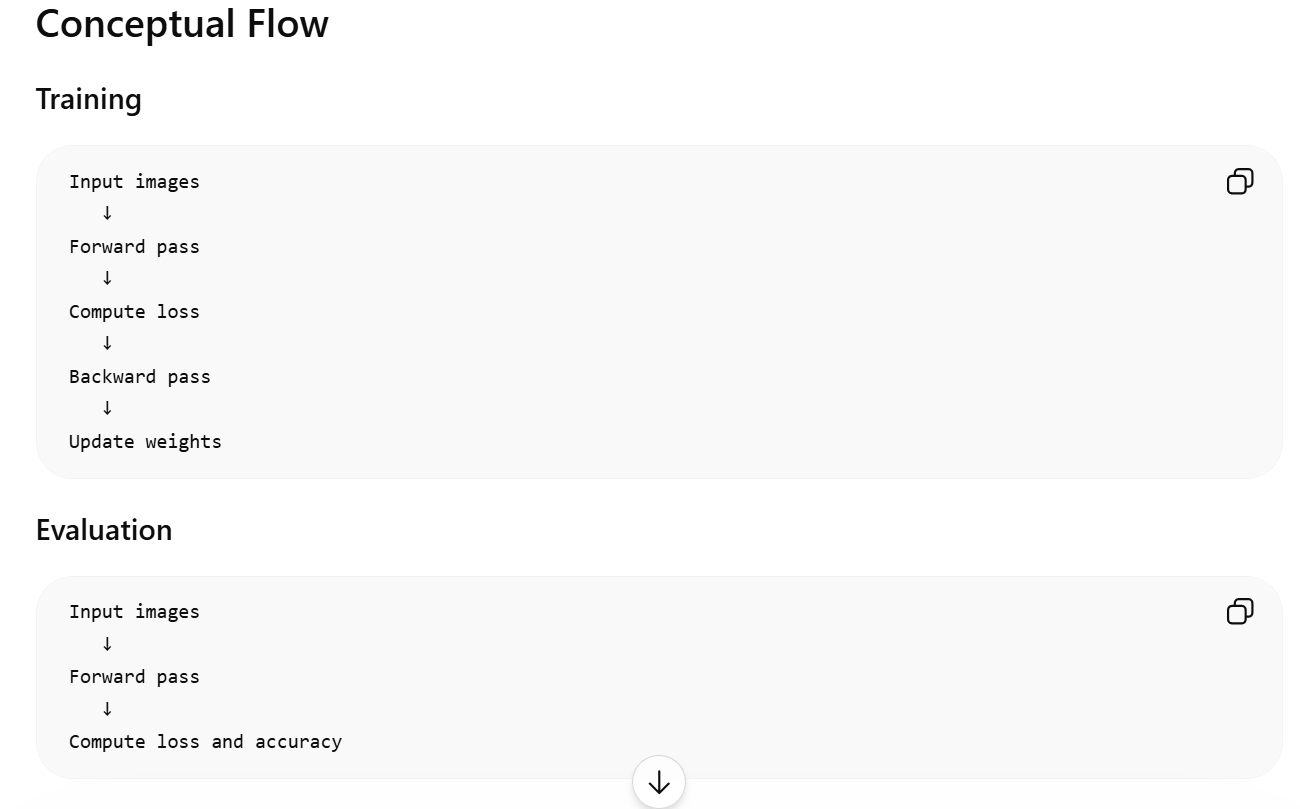

In [22]:
#@title Training and Evaluation Function

def train_one_epoch(model, loader, criterion, optimizer):
    model.train() # Set the model to training mode

    # Initialize the tracking variables which will accumulates across epochs
    total_loss = 0.0
    correct = 0
    total = 0

    # Loop over mini-batches
    for images, labels in loader:
        images = images.to(DEVICE) # Move tensors to cpu / gpu
        labels = labels.to(DEVICE)

        optimizer.zero_grad() # Initialize gradients

        # Forward Pass
        outputs = model(images) # Compute predictions
        loss = criterion(outputs, labels) # Compute the loss

        # Backpropagation
        loss.backward() # Computes loss gradients
        optimizer.step() # Update the weight / parameter using adjusted gradient

        total_loss += loss.item() * images.size(0) # Count the accumulate loss
        preds = outputs.argmax(dim=1) # Get the prediction
        correct += (preds == labels).sum().item() # Count the correct predictions
        total += labels.size(0) # Count total sample

    return total_loss / total, correct / total


@torch.no_grad() # Disable gradient computation for faster execution and lower memory usage.
def evaluate(model, loader, criterion):
    model.eval() # Switch to evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Compute the total loss, and accuracy
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [23]:
#@title Epoch Training
def train(model, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-5,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    patience_counter = 0
    EARLY_STOP_PATIENCE = 3

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr < prev_lr:
            print(f"  => LR reduced: {prev_lr:.2e} => {new_lr:.2e}")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%"
        )

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  => New best model saved. Val Acc: {val_acc*100:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    return history

In [24]:
#@title Display Training/Validation Curve

def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"], label="Validation")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy Loss")
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot([x * 100 for x in history["train_acc"]], label="Train")
    ax2.plot([x * 100 for x in history["val_acc"]], label="Validation")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

In [25]:
#@title Display Sample Prediction Result

@torch.no_grad()
def predict_batch(model, loader, class_names, n=8):
    model.eval()

    images, labels = next(iter(loader))
    images_device = images[:n].to(DEVICE)

    outputs = model(images_device)
    preds = outputs.argmax(dim=1).cpu()

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(n):
        img = images[i].squeeze().numpy()
        img = img * 0.255 + 0.507  # approximate un-normalization

        axes[i].imshow(img, cmap="gray")

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"T: {true_label}\nP: {pred_label}",
            color=color,
            fontsize=8,
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()

Device: cuda
Fetching dataset via kagglehub (cached if already downloaded)...
Using Colab cache for faster access to the 'face-expression-recognition-dataset' dataset.
Dataset path: /kaggle/input/face-expression-recognition-dataset
No test folder found. Reusing validation as test set.
Train: 28,821
Validation: 7,066
Test: 7,066
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class label mapping:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Sample labels:
[2, 3, 5, 2, 2, 6, 5, 5, 5, 3]
['fear', 'happy', 'sad', 'fear', 'fear', 'surprise', 'sad', 'sad', 'sad', 'happy']

Model parameters: 2,488,423

-- Training --
  => LR reduced: 1.00e-03 => 9.94e-04
Epoch   1/20 | Train Loss: 1.8310, Acc: 25.60% | Val Loss: 1.6484, Acc: 35.00%
  => New best model saved. Val Acc: 35.00%
  => LR reduced: 9.94e-04 => 9.76e-04
Epoch   2/20 | Train Loss: 1.5712, Acc: 38.09% | Val Loss: 1.3912, Acc: 46.16%
  => New best model saved. Val Acc: 46

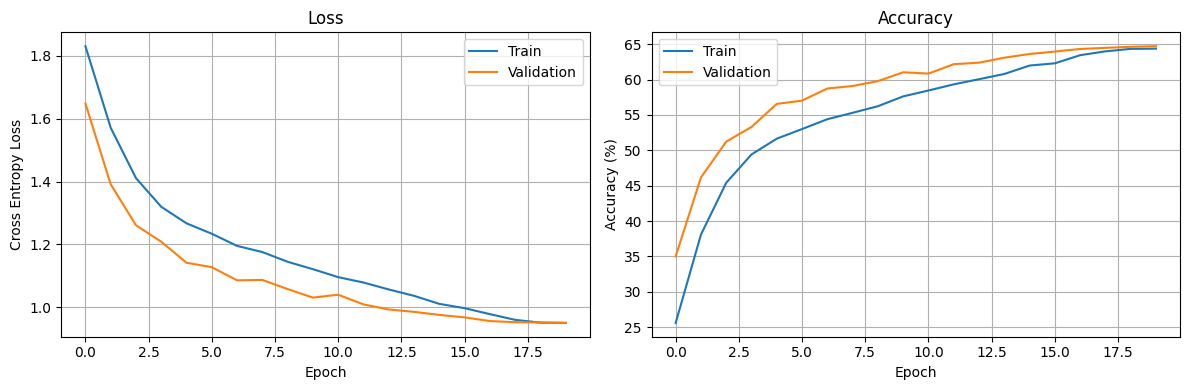

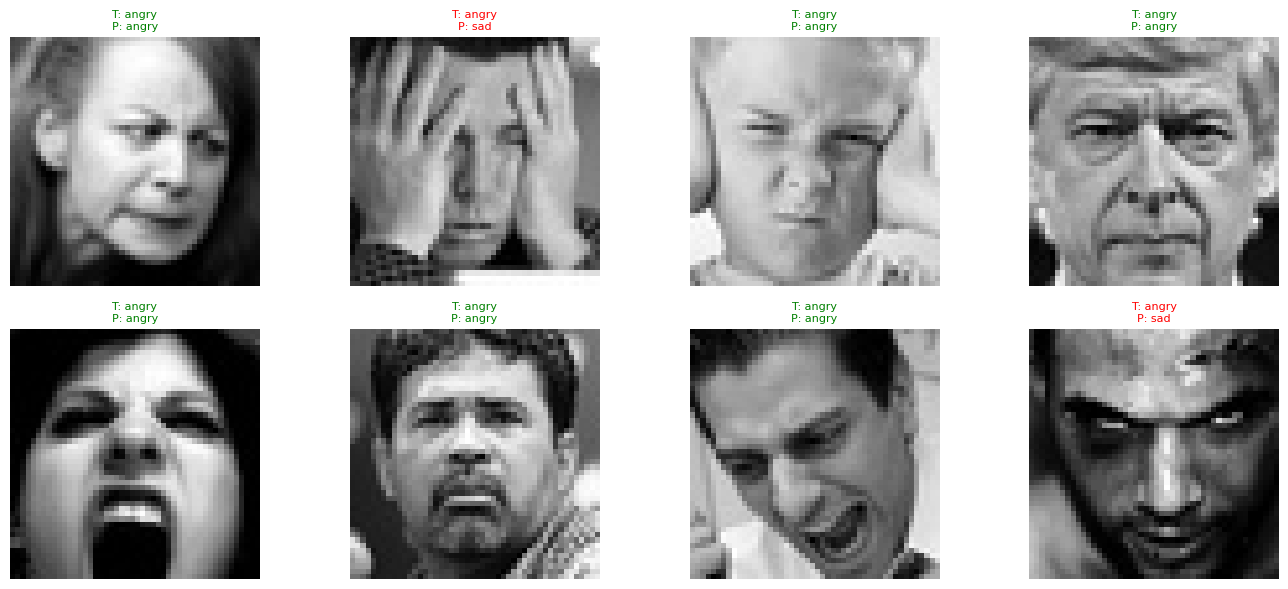

In [26]:
#@title Main Function
def main():
    global EXPRESSION_LABELS

    print(f"Device: {DEVICE}")

    # Load data
    train_loader, val_loader, test_loader, EXPRESSION_LABELS = get_dataloaders()

    print("\nClass label mapping:")
    for idx, name in enumerate(EXPRESSION_LABELS):
        print(f"  {idx}: {name}")

    # Sanity check labels
    images, labels = next(iter(train_loader))
    print("\nSample labels:")
    print(labels[:10].tolist())
    print([EXPRESSION_LABELS[i] for i in labels[:10].tolist()])

    # Model
    model = FacialExpressionCNN(
        num_classes=CONFIG["num_classes"]
    ).to(DEVICE)

    print(f"\nModel parameters: {count_parameters(model):,}")

    # Train
    print("\n-- Training --")
    history = train(
        model,
        train_loader,
        val_loader,
        CONFIG["epochs"],
    )

    # Load best model
    model.load_state_dict(
        torch.load("best_model.pth", map_location=DEVICE)
    )

    # Final evaluation
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    print("\n-- Test Results --")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    # Plot curves
    plot_training_curves(history)

    # Show predictions
    predict_batch(model, test_loader, EXPRESSION_LABELS)


if __name__ == "__main__":
    main()